# 12. Accuracy Dashboard & Correlation Matrix

The **exact same numbers shown on the Admin Dashboard** (accuracy cards and correlation matrix) — computed from the same log files via `ml/model_stats.py`, the single source of truth shared with the Flask app. What you see here is what the website shows.

In [1]:
import sys, os, json, math, matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('../../ml'))
from model_stats import model_cards, correlation_matrix

## 1. Model Accuracy (same as admin dashboard)

In [2]:
for card in model_cards():
    print(f"== {card['name']} model ==")
    print(f"   Accuracy  : {card['accuracy']}%")
    print(f"   Macro F1  : {card['macro_f1']}")
    print(f"   Trained   : {card['last_trained']}  ({card['train_samples']} train / {card['test_samples']} test)")
    if card['per_class']:
        print("   Per-class : " + ", ".join(
            f"{pc['label']} (P {pc['precision']:.2f} / R {pc['recall']:.2f} / F1 {pc['f1']:.2f} / n={pc['support']})"
            for pc in card['per_class']))
    print()

== Category model ==
   Accuracy  : 96.81%
   Macro F1  : 0.9687
   Trained   : 2026-08-08 13:20:37  (5770 train / 1443 test)
   Per-class : IT Support (P 0.98 / R 0.98 / F1 0.98 / n=161), Hostels (P 0.94 / R 0.94 / F1 0.94 / n=145), Academics (P 0.97 / R 0.95 / F1 0.96 / n=146), Fees / Finance (P 0.96 / R 0.97 / F1 0.97 / n=147), Maintenance (P 0.94 / R 0.95 / F1 0.95 / n=155), Transport (P 0.96 / R 1.00 / F1 0.98 / n=163), Security / Discipline (P 0.98 / R 0.97 / F1 0.97 / n=140), Administration (P 0.97 / R 0.92 / F1 0.94 / n=139), Library (P 0.98 / R 1.00 / F1 0.99 / n=129), Canteen (P 1.00 / R 1.00 / F1 1.00 / n=118)

== Sentiment model ==
   Accuracy  : 99.71%
   Macro F1  : 0.9971
   Trained   : 2026-08-08 22:31:51  (9600 train / 2400 test)
   Per-class : negative (P 1.00 / R 0.99 / F1 1.00 / n=805), positive (P 0.99 / R 1.00 / F1 1.00 / n=821), neutral (P 1.00 / R 1.00 / F1 1.00 / n=774)

== Priority model ==
   Accuracy  : 99.21%
   Macro F1  : 0.9921
   Trained   : 2026-08-08 

## 2. Correlation Matrix (same as admin dashboard)

Pearson correlation between numeric complaint signals in `data/sentiment_dataset.csv`:
- **sentiment** — negative=-1, neutral=0, positive=+1
- **priority** — low=1, medium=2, high=3
- **text_length** — complaint length in characters
- **polarity** — VADER polarity score

In [3]:
corr = correlation_matrix()
labels, matrix = corr['labels'], corr['matrix']
print(f"{corr['rows']} samples")
print(' '.join([' ' * 14] + [f'{l:>12}' for l in labels]))
for i, l in enumerate(labels):
    print(f"{l:>14} " + ' '.join(f'{v:>12.3f}' for v in matrix[i]))

12000 samples
                  sentiment     priority  text_length     polarity
     sentiment        1.000       -0.823       -0.798        0.928
      priority       -0.823        1.000        0.711       -0.803
   text_length       -0.798        0.711        1.000       -0.757
      polarity        0.928       -0.803       -0.757        1.000


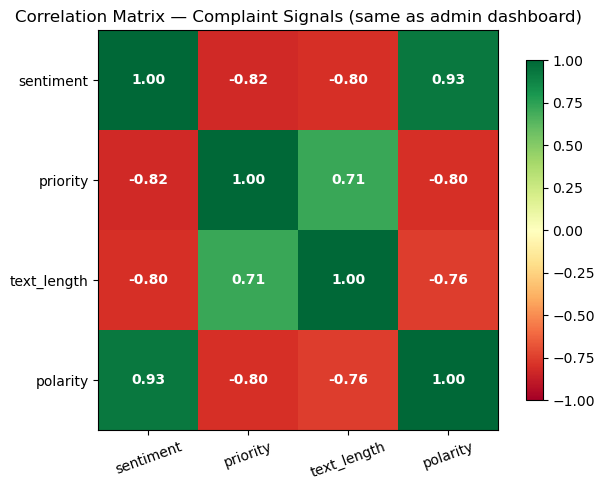

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(matrix, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=20)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{matrix[i][j]:.2f}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if abs(matrix[i][j]) > 0.5 else 'black')
ax.set_title('Correlation Matrix — Complaint Signals (same as admin dashboard)')
fig.colorbar(im, shrink=0.85)
plt.tight_layout(); plt.show()

**Reading the matrix** — positive values (red) mean the two signals rise together. The strongest driver is usually polarity → sentiment; check whether priority correlates with sentiment or just with text length, which tells us whether high priority is driven by negativity or by verbosity.